In [1]:
import sys
!{sys.executable} -m pip install causationentropy -q

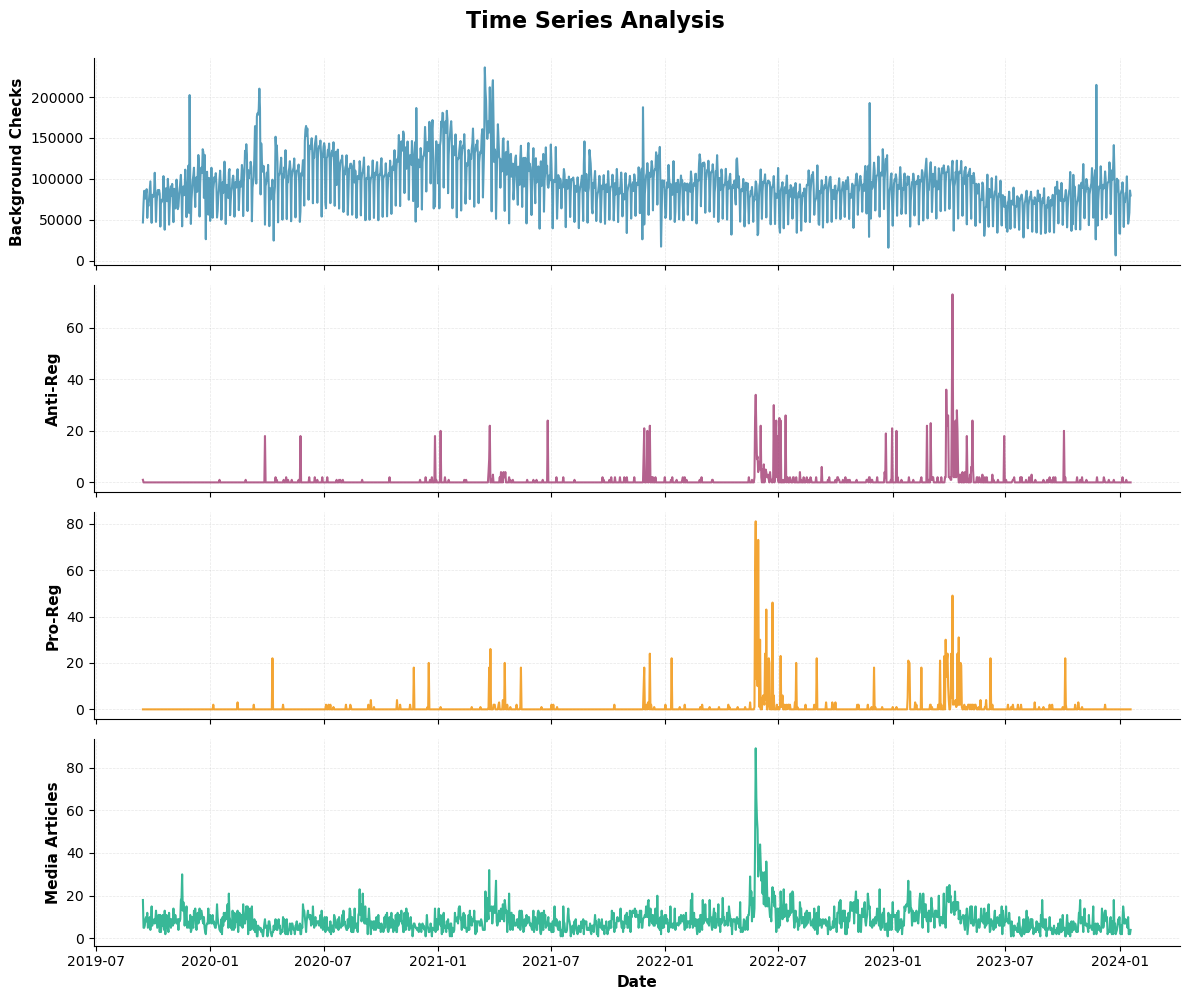

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from causationentropy.core import discover_network

# Load data
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# Count articles per day
proquest_df['PubDate'] = pd.to_datetime(proquest_df['PubDate'])
articles_per_day = proquest_df.groupby('PubDate').size().reset_index(name='Media Articles')

# Prepare main dataframe
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Merge datasets
merged = pd.merge(
    df, 
    articles_per_day, 
    left_on='timestamp', 
    right_on='PubDate', 
    how='inner'
).drop(columns=['PubDate'])

# Rename columns for clarity
merged = merged.rename(columns={
    'bg_checks': 'Background Checks',
    'anti_reg': 'Anti-Reg',
    'pro_reg': 'Pro-Reg'
})

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold', y=0.995)

# Define colors
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
variables = ['Background Checks', 'Anti-Reg', 'Pro-Reg', 'Media Articles']

# Plot each variable
for ax, var, color in zip(axes, variables, colors):
    ax.plot(merged['timestamp'], merged[var], color=color, linewidth=1.5, alpha=0.8)
    ax.set_ylabel(var, fontsize=11, fontweight='600')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Set x-axis label only on bottom plot
axes[-1].set_xlabel('Date', fontsize=11, fontweight='600')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# --- Load ---
df = pd.read_csv("data/all_dailies_reg.csv")
proquest_df = pd.read_csv("data/proquest.csv")

# --- Normalize to date-only keys (avoid time-of-day mismatches) ---
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.floor("D")

proquest_df["PubDate"] = pd.to_datetime(proquest_df["PubDate"])
proquest_df["date"] = proquest_df["PubDate"].dt.floor("D")

# --- Count articles per day ---
articles_per_day = (
    proquest_df.groupby("date").size().reset_index(name="Media Articles")
)

# --- Merge: keep ALL background-check rows (left join), fill missing media with 0 ---
merged = (
    df.merge(articles_per_day, on="date", how="left")
      .drop(columns=["PubDate"], errors="ignore")
      .rename(columns={
          "bg_checks": "Background Checks",
          "anti_reg": "Anti-Reg",
          "pro_reg": "Pro-Reg"
      })
)

merged["Media Articles"] = merged["Media Articles"].fillna(0)


print("Missing Background Checks after left-merge:", merged["Background Checks"].isna().sum())
if merged["Background Checks"].isna().any():
    # If this prints >0, the source CSV itself has gaps for those dates
    print(merged.loc[merged["Background Checks"].isna(), ["date", "Background Checks"]].head(20))


merged = merged.set_index("date").sort_index()
merged = merged.asfreq("D")  # align to daily; should NOT produce NaNs in Background Checks now

result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)
merged["Deseasonalized Background Checks"] = result.observed - result.seasonal

Missing Background Checks after left-merge: 0


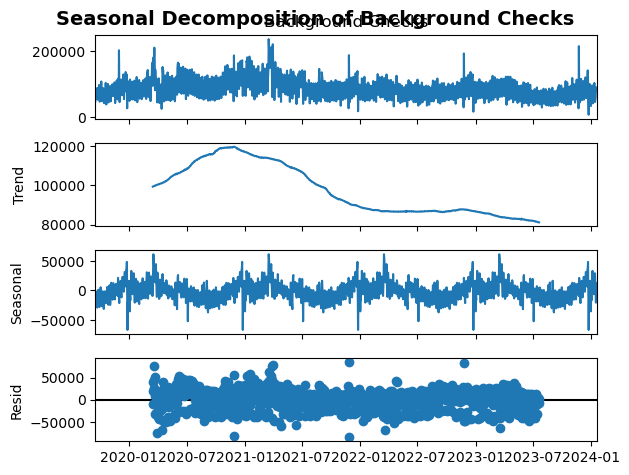

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure timestamp is the index
merged = merged.set_index("timestamp").asfreq("D")  # daily frequency

# Classical seasonal decomposition (additive model is typical for counts)
result = seasonal_decompose(merged["Background Checks"], model="additive", period=365)

# Deseasonalized series = observed - seasonal
merged["Background Checks_deseasonalized"] = result.observed - result.seasonal

# Plot decomposition
result.plot()
plt.suptitle("Seasonal Decomposition of Background Checks", fontsize=14, fontweight='bold')
plt.show()

In [5]:
merged.head()

,Background Checks,Anti-Reg,Pro-Reg,Media Articles,Deseasonalized Background Checks,Background Checks_deseasonalized
timestamp,,,,,,
2019-09-15,46741,1,0,18.0,58848.885371,58848.885371
2019-09-16,69574,0,0,5.0,78874.446102,78874.446102
2019-09-17,85434,0,0,5.0,87451.331033,87451.331033
2019-09-18,83936,0,0,6.0,85801.708202,85801.708202
2019-09-19,75939,0,0,9.0,89730.671673,89730.671673


In [6]:
from causationentropy.core import discover_network
from sklearn.preprocessing import StandardScaler
import numpy as np

data = merged[["Deseasonalized Background Checks", 'Anti-Reg', 'Pro-Reg', 'Media Articles']]

scaler = StandardScaler()
data = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns,
    index=data.index
)

network = discover_network(
    data,
    information='gaussian',
    max_lag=7,              # Maximum time lag to consider
    alpha_forward=0.005,     # Forward selection significance
    alpha_backward=0.005,    # Backward elimination significance
    n_shuffles=200          # Permutation test iterations
)

Estimating edges for node 0 (Deseasonalized Background Checks)


/home/kslote/anaconda3/lib/python3.11/site-packages/causationentropy/core/information/conditional_mutual_information.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  cmi = 0.5 * (SXZ + SYZ - SZ - SXYZ)


Estimating edges for node 1 (Anti-Reg)
Estimating edges for node 2 (Pro-Reg)
Estimating edges for node 3 (Media Articles)


In [7]:
data.corr()

,Deseasonalized Background Checks,Anti-Reg,Pro-Reg,Media Articles
Deseasonalized Background Checks,1.000000,-0.022541,-0.039989,-0.166451
Anti-Reg,-0.022541,1.000000,0.405579,0.304690
Pro-Reg,-0.039989,0.405579,1.000000,0.427082
Media Articles,-0.166451,0.304690,0.427082,1.000000


/tmp/ipykernel_456951/2183336248.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
/tmp/ipykernel_456951/2183336248.py:67: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
/tmp/ipykernel_456951/2183336248.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
/tmp/ipykernel_456951/2183336248.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated 

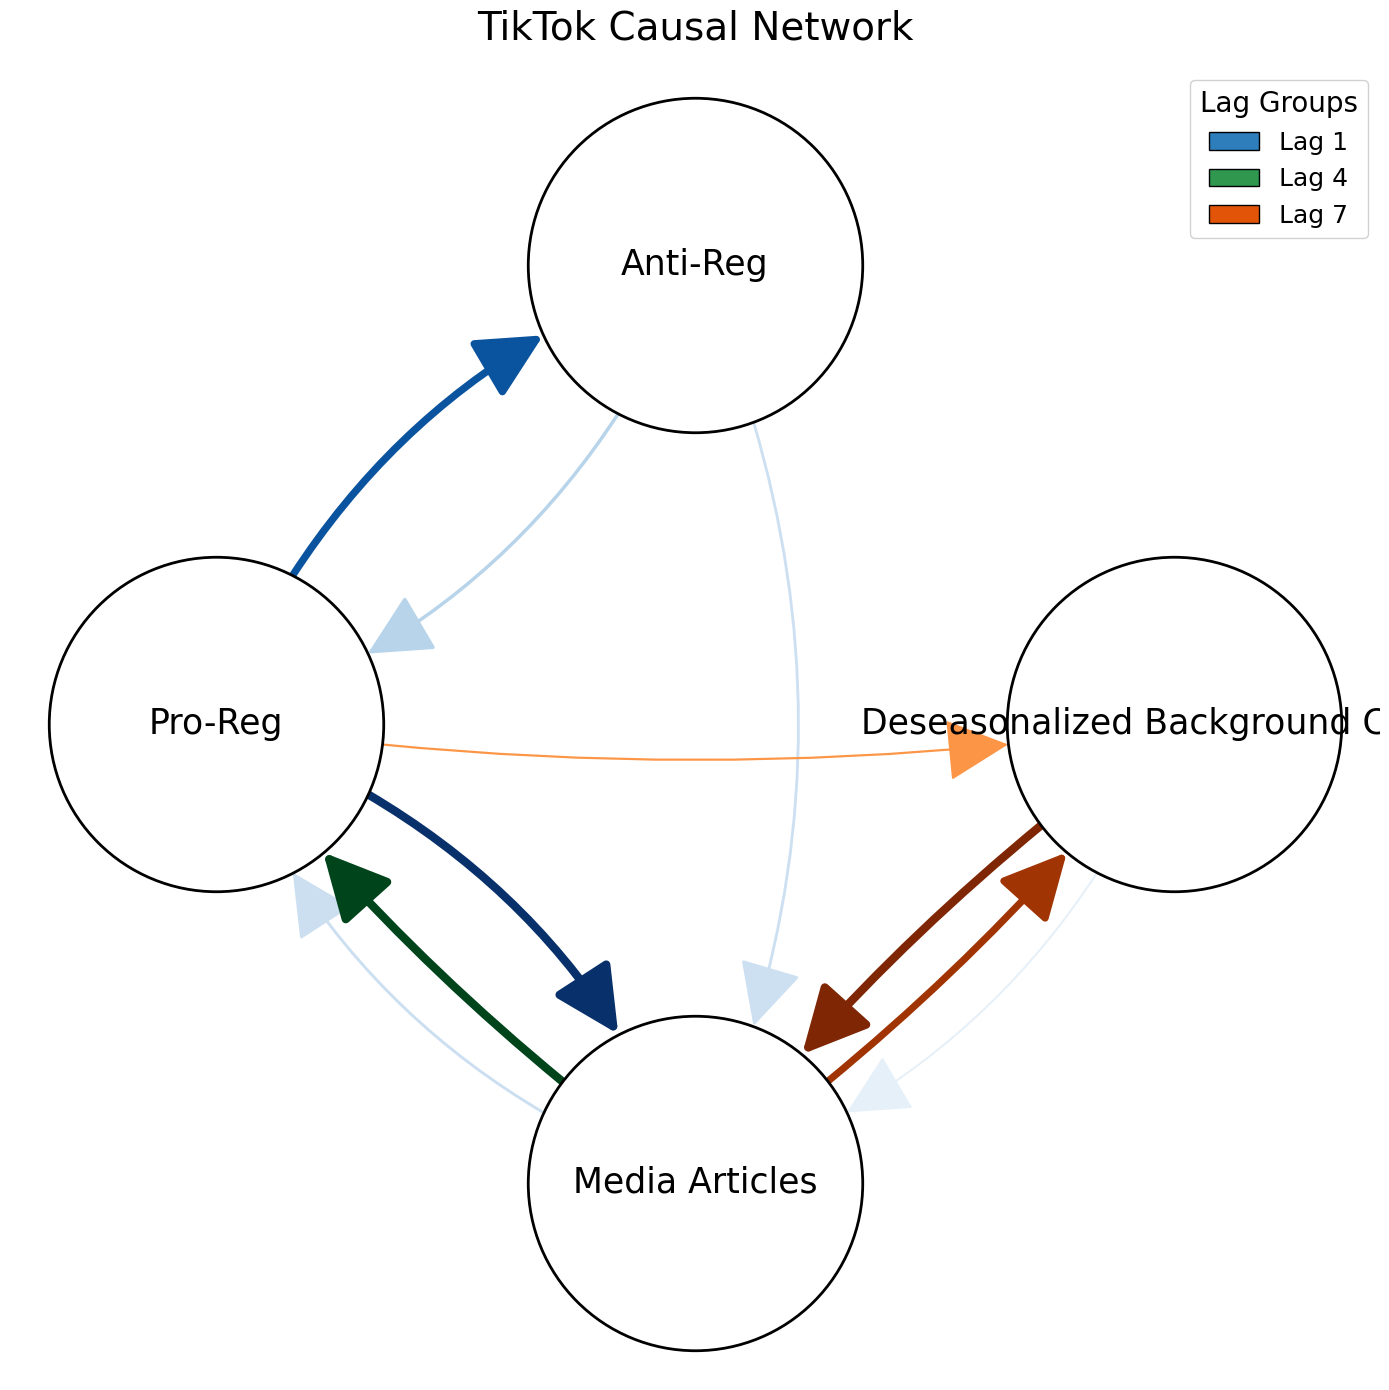

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from collections import defaultdict
from matplotlib.patches import Patch

# Configuration
CONFIG = {
    'node_size': 58000,
    'arrowsize': 100,
    'label_fontsize': 25,
    'figsize': (14, 14),  # Increased figure size
    'edge_width_range': (1.0, 6.0),
    'node_linewidth': 2.0,
    'layout': 'circular',
    'colormaps': ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys', 'YlOrBr']
}

# Get layout positions
pos = nx.circular_layout(network)

# Extract edge data
edge_data = defaultdict(list)
for u, v, k, data in network.edges(keys=True, data=True):
    lag = data.get('lag', 0)
    cmi = max(0.0, float(data.get('cmi', 0.0)))
    edge_data[lag].append((u, v, cmi))

# Create plot
fig, ax = plt.subplots(figsize=CONFIG['figsize'])

# Draw nodes
nx.draw_networkx_nodes(
    network, pos,
    node_size=CONFIG['node_size'],
    node_color='white',
    edgecolors='black',
    linewidths=CONFIG['node_linewidth'],
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(network, pos, font_size=CONFIG['label_fontsize'], ax=ax)

# Draw edges by lag
for i, (lag, edges) in enumerate(sorted(edge_data.items())):
    if not edges:
        continue
    
    # Extract CMI values and normalize
    cmis = np.array([e[2] for e in edges])
    max_cmi = cmis.max() if cmis.max() > 0 else 1.0
    
    # Calculate edge properties
    widths = CONFIG['edge_width_range'][0] + \
             (CONFIG['edge_width_range'][1] - CONFIG['edge_width_range'][0]) * (cmis / max_cmi)
    
    # Make colors darker for lag 7
    if lag == 7:
        normalized_cmis = 0.4 + 0.6 * (cmis / max_cmi)
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
    else:
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
    
    # Draw edges for this lag
    nx.draw_networkx_edges(
        network, pos,
        edgelist=[(e[0], e[1]) for e in edges],
        edge_color=colors,
        width=widths,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=CONFIG['arrowsize'],
        connectionstyle=f'arc3,rad={0.15 * (i - len(edge_data)/2)}',
        node_size=CONFIG['node_size'],
        ax=ax
    )

# Create legend (removed duplicate legend code)
legend_elements = []
for i, lag in enumerate(sorted(edge_data.keys())):
    colormap = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])
    color = colormap(0.7)
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=f'Lag {lag}'))

# Add legend with better positioning
ax.legend(handles=legend_elements, loc='upper right', fontsize=18, 
          title='Lag Groups', title_fontsize=20, framealpha=0.9)

# Set axis properties
ax.set_axis_off()
ax.set_title('TikTok Causal Network', fontsize=28, pad=20)

# Adjust margins to ensure everything fits
plt.margins(0.15)  # Add 15% margin around the plot
plt.tight_layout()
plt.savefig("network.pdf", dpi=300)
plt.show()

In [9]:
import networkx as nx

PRO = "Pro-Reg"
MEDIA = "Media Articles"
BC = "Deseasonalized Background Checks"

allowed_pairs = {
    (PRO, MEDIA),
    (MEDIA, BC),
    (PRO, BC),
}

# Build a new pruned MultiDiGraph containing only allowed directed edges
pruned = nx.MultiDiGraph()
pruned.add_nodes_from([PRO, MEDIA, BC])  # keep just these nodes (optional)

for u, v, k, d in network.edges(keys=True, data=True):
    if (u, v) in allowed_pairs:
        pruned.add_edge(u, v, key=k, **d)

/tmp/ipykernel_456951/2034294377.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
/tmp/ipykernel_456951/2034294377.py:67: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
/tmp/ipykernel_456951/2034294377.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
/tmp/ipykernel_456951/2034294377.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated 

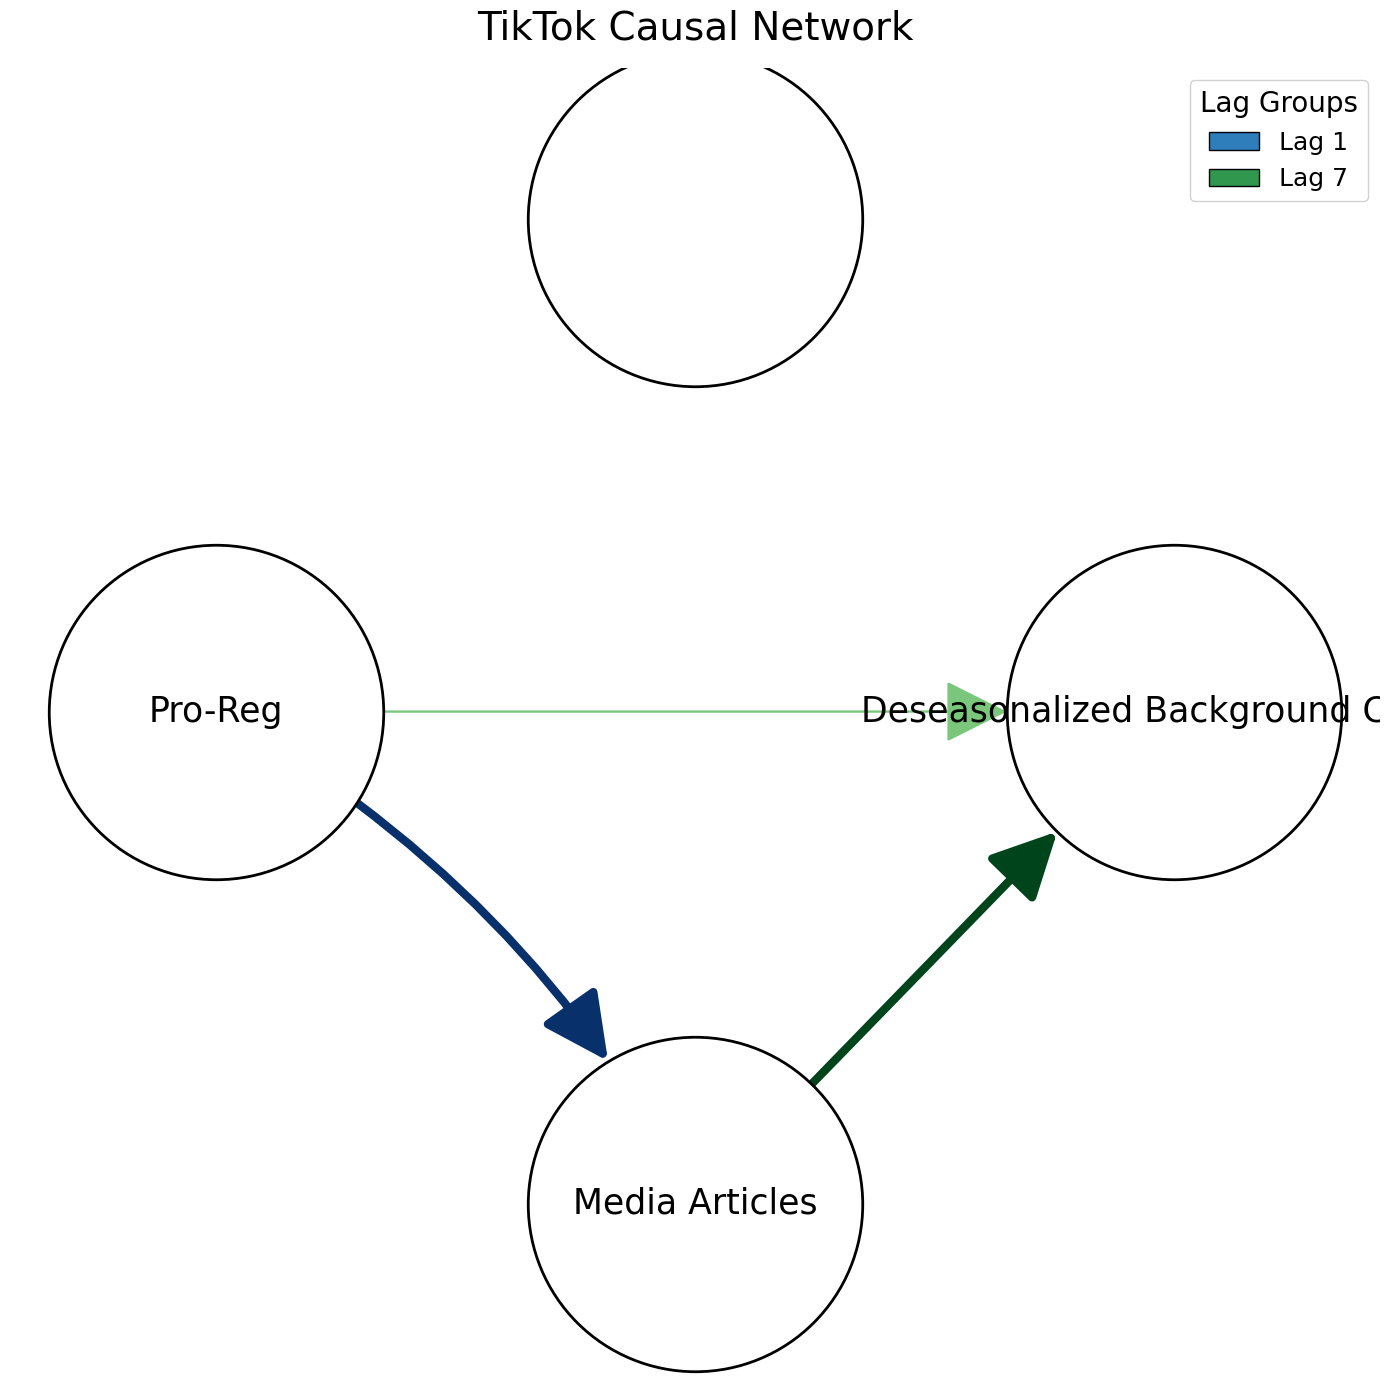

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from collections import defaultdict
from matplotlib.patches import Patch

# Configuration
CONFIG = {
    'node_size': 58000,
    'arrowsize': 100,
    'label_fontsize': 25,
    'figsize': (14, 14),  # Increased figure size
    'edge_width_range': (1.0, 6.0),
    'node_linewidth': 2.0,
    'layout': 'circular',
    'colormaps': ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys', 'YlOrBr']
}

# Get layout positions
pos = nx.circular_layout(network)

# Extract edge data
edge_data = defaultdict(list)
for u, v, k, data in pruned.edges(keys=True, data=True):
    lag = data.get('lag', 0)
    cmi = max(0.0, float(data.get('cmi', 0.0)))
    edge_data[lag].append((u, v, cmi))

# Create plot
fig, ax = plt.subplots(figsize=CONFIG['figsize'])

# Draw nodes
nx.draw_networkx_nodes(
    network, pos,
    node_size=CONFIG['node_size'],
    node_color='white',
    edgecolors='black',
    linewidths=CONFIG['node_linewidth'],
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(pruned, pos, font_size=CONFIG['label_fontsize'], ax=ax)

# Draw edges by lag
for i, (lag, edges) in enumerate(sorted(edge_data.items())):
    if not edges:
        continue
    
    # Extract CMI values and normalize
    cmis = np.array([e[2] for e in edges])
    max_cmi = cmis.max() if cmis.max() > 0 else 1.0
    
    # Calculate edge properties
    widths = CONFIG['edge_width_range'][0] + \
             (CONFIG['edge_width_range'][1] - CONFIG['edge_width_range'][0]) * (cmis / max_cmi)
    
    # Make colors darker for lag 7
    if lag == 7:
        normalized_cmis = 0.4 + 0.6 * (cmis / max_cmi)
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(normalized_cmis)
    else:
        colors = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])(cmis / max_cmi)
    
    # Draw edges for this lag
    nx.draw_networkx_edges(
        pruned, pos,
        edgelist=[(e[0], e[1]) for e in edges],
        edge_color=colors,
        width=widths,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=CONFIG['arrowsize'],
        connectionstyle=f'arc3,rad={0.15 * (i - len(edge_data)/2)}',
        node_size=CONFIG['node_size'],
        ax=ax
    )

# Create legend (removed duplicate legend code)
legend_elements = []
for i, lag in enumerate(sorted(edge_data.keys())):
    colormap = plt.cm.get_cmap(CONFIG['colormaps'][i % len(CONFIG['colormaps'])])
    color = colormap(0.7)
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=f'Lag {lag}'))

# Add legend with better positioning
ax.legend(handles=legend_elements, loc='upper right', fontsize=18, 
          title='Lag Groups', title_fontsize=20, framealpha=0.9)

# Set axis properties
ax.set_axis_off()
ax.set_title('TikTok Causal Network', fontsize=28, pad=20)

# Adjust margins to ensure everything fits
plt.margins(0.15)  # Add 15% margin around the plot
plt.tight_layout()
plt.savefig("pruned.pdf", dpi=300)
plt.show()

In [11]:
import pandas as pd

df_parents = merged.copy()
# Start from original data
df_lagged = pd.DataFrame(index=df_parents.index)

# Collect all nodes that appear in the pruned network
nodes_in_graph = set(pruned.nodes)

# Add original (unshifted) versions of all nodes
for node in nodes_in_graph:
    if node in df_parents.columns:
        df_lagged[node] = df_parents[node]

# Add lagged columns for every surviving edge
for u, v, k, data in network.edges(keys=True, data=True):
    lag = int(data["lag"])
    
    col_name = f"{u}_lag{lag}"
    
    # Align X_{t-lag} with Y_t
    df_lagged[col_name] = df_parents[u].shift(lag)

# Drop rows with missing values caused by lagging
df_lagged = df_lagged.dropna()

df_lagged.head()

,Media Articles,Deseasonalized Background Checks,Pro-Reg,Deseasonalized Background Checks_lag7,Deseasonalized Background Checks_lag1,Anti-Reg_lag1,Pro-Reg_lag7,Pro-Reg_lag1,Media Articles_lag7,Media Articles_lag4,Media Articles_lag1
timestamp,,,,,,,,,,,
2019-09-22,12.0,58136.632403,0,58848.885371,116216.153864,0.0,0.0,0.0,18.0,6.0,8.0
2019-09-23,5.0,70763.741992,0,78874.446102,58136.632403,0.0,0.0,0.0,5.0,9.0,12.0
2019-09-24,6.0,67079.647015,0,87451.331033,70763.741992,0.0,0.0,0.0,5.0,10.0,5.0
2019-09-25,9.0,76176.582175,0,85801.708202,67079.647015,0.0,0.0,0.0,6.0,8.0,6.0
2019-09-26,10.0,105199.532860,0,89730.671673,76176.582175,0.0,0.0,0.0,9.0,12.0,9.0


In [13]:
Y = "Deseasonalized Background Checks"

parents = []
for u, v, key, data in network.in_edges(Y, keys=True, data=True):
    parents.append((u, data["lag"]))

parents

[('Media Articles', 7), ('Pro-Reg', 7)]

In [14]:
import pingouin as pg

Y = "Deseasonalized Background Checks"
x_lag = 7

# Use the LAGGED X that corresponds to the edge you care about
X_col = f"Pro-Reg_lag{x_lag}"

# Covariates: all other surviving parents of Y at their lags
covars = [
    f"{var}_lag{lag}"
    for (var, lag) in parents
    if not (var == "Pro-Reg" and lag == x_lag)
]

# Keep only needed columns and align rows
cols_needed = [Y, X_col] + covars
df_test = df_lagged[cols_needed].dropna()

result = pg.partial_corr(
    data=df_test,
    x=X_col,
    y=Y,
    covar=covars
)

print(result)

            n         r         CI95%     p-val
pearson  1581  0.073189  [0.02, 0.12]  0.003605


In [15]:
df_test

,Deseasonalized Background Checks,Pro-Reg_lag7,Media Articles_lag7
timestamp,,,
2019-09-22,58136.632403,0.0,18.0
2019-09-23,70763.741992,0.0,5.0
2019-09-24,67079.647015,0.0,5.0
2019-09-25,76176.582175,0.0,6.0
2019-09-26,105199.532860,0.0,9.0
...,...,...,...
2024-01-15,38572.544732,0.0,7.0
2024-01-16,61349.582175,0.0,7.0
2024-01-17,106216.710942,0.0,9.0


In [20]:
df_full = pd.DataFrame(index=df_parents.index)

# Current time variables
df_full["Media"] = df_parents["Media Articles"]
df_full["Background"] = df_parents["Deseasonalized Background Checks"]

# Lagged predictors from your pruned network
df_full["Pro-Reg_lag1"] = df_parents["Pro-Reg"].shift(1)
df_full["Pro-Reg_lag7"] = df_parents["Pro-Reg"].shift(7)
df_full["Media_lag7"]   = df_parents["Media Articles"].shift(7)

# Align
df_full = df_full.dropna()

df_full.head()

,Media,Background,Pro-Reg_lag1,Pro-Reg_lag7,Media_lag7
timestamp,,,,,
2019-09-22,12.0,58136.632403,0.0,0.0,18.0
2019-09-23,5.0,70763.741992,0.0,0.0,5.0
2019-09-24,6.0,67079.647015,0.0,0.0,5.0
2019-09-25,9.0,76176.582175,0.0,0.0,6.0
2019-09-26,10.0,105199.532860,0.0,0.0,9.0


In [32]:
import pingouin as pg

Y = "Background"
X_col = "Pro-Reg_lag7"
covars = ["Media_lag7", "Pro-Reg_lag1", "Media_lag7"]

result = pg.partial_corr(
    data=df_full,
    x=X_col,
    y=Y,
    covar=covars
)

print(result)

            n         r         CI95%    p-val
pearson  1581  0.072863  [0.02, 0.12]  0.00378


In [33]:
covars

['Media_lag7', 'Pro-Reg_lag1', 'Media_lag7']

In [28]:
df_full

,Media,Background,Pro-Reg_lag1,Pro-Reg_lag7,Media_lag7
timestamp,,,,,
2019-09-22,12.0,58136.632403,0.0,0.0,18.0
2019-09-23,5.0,70763.741992,0.0,0.0,5.0
2019-09-24,6.0,67079.647015,0.0,0.0,5.0
2019-09-25,9.0,76176.582175,0.0,0.0,6.0
2019-09-26,10.0,105199.532860,0.0,0.0,9.0
...,...,...,...,...,...
2024-01-15,2.0,38572.544732,0.0,0.0,7.0
2024-01-16,3.0,61349.582175,0.0,0.0,7.0
2024-01-17,2.0,106216.710942,0.0,0.0,9.0


In [24]:
import pingouin as pg

# Target and lag of interest
Y = "Background Checks"
lag = 7

result = pg.partial_corr(
        data=df_full,
        x=X_col,
        y=Y,
        covar=covars
    )

print(result)

AssertionError: columns are not in dataframe.

In [25]:
df_full

,Media,Background,Pro-Reg_lag1,Pro-Reg_lag7,Media_lag7
timestamp,,,,,
2019-09-22,12.0,58136.632403,0.0,0.0,18.0
2019-09-23,5.0,70763.741992,0.0,0.0,5.0
2019-09-24,6.0,67079.647015,0.0,0.0,5.0
2019-09-25,9.0,76176.582175,0.0,0.0,6.0
2019-09-26,10.0,105199.532860,0.0,0.0,9.0
...,...,...,...,...,...
2024-01-15,2.0,38572.544732,0.0,0.0,7.0
2024-01-16,3.0,61349.582175,0.0,0.0,7.0
2024-01-17,2.0,106216.710942,0.0,0.0,9.0


In [19]:
df_parents["Pro-Reg"].value_counts(dropna=False).head(10)

Pro-Reg
0     1385
2       76
1       52
3       14
4        9
20       7
22       6
18       6
24       5
23       3
Name: count, dtype: int64